<a href="https://colab.research.google.com/github/codeKrantz/PyTorch-for-deep-learning/blob/main/01_pytorch_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#PyTorch Workflow

In [1]:
what_were_covering = {1: "data",
                      2: "build a model",
                      3: "fitting a model (training)",
                      4: "making predictions/inferences",
                      5: "saving and loading models",
                      6: "Putting it all together"}

In [2]:
import torch
from torch import nn #nn contains building blocks for building networks
import matplotlib.pyplot as plt

#check version
torch.__version__

'2.11.0+cu128'

## 1. Data: preparing and loading
* Excel Sheets
* Images
* Videos
* Audio
* DNA
* Text

In [3]:
#Lets us linear regression

#Creating know parameters
weight = 0.7
bias = 0.3

start = 0
end = 1
step  = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
# y = mx + c
y = weight * X + bias

X[:10], y[:10],


(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [4]:
#they are the same length
len(X), len(y)

(50, 50)

### Splitting Data into Trainning and Test Sets

In [5]:
#using an 80/20 split

trian_split = int(0.8 * len(X))
X_train, y_train = X[:trian_split], y[:trian_split]
X_test, y_test = X[trian_split:], y[trian_split:]

#number of sets/samples
len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [6]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

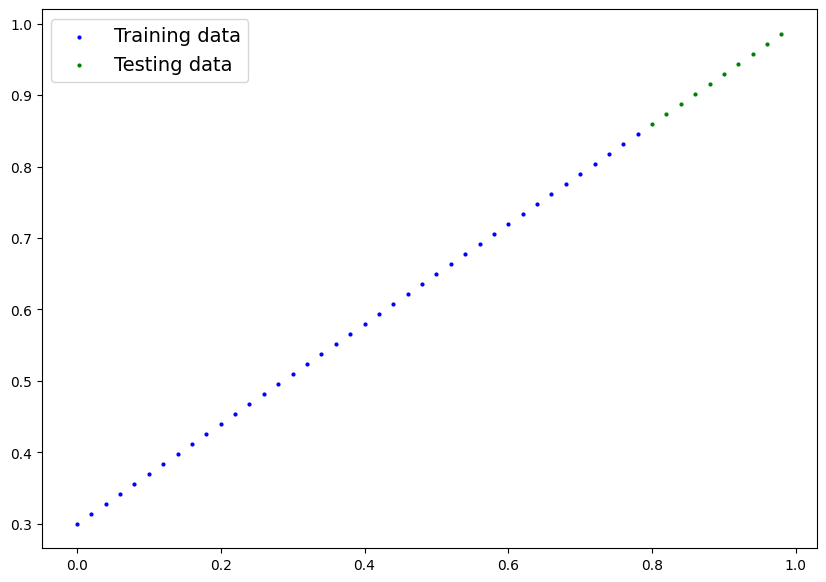

In [7]:
plot_predictions()

## Build Model

In [8]:
# Create a Linear Regression model class
class LinearRegressionModel(nn.Module): # <- almost everything in PyTorch is a nn.Module (think of this as neural network lego blocks)
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, # <- start with random weights (this will get adjusted as the model learns)
                                                dtype=torch.float), # <- PyTorch loves float32 by default
                                   requires_grad=True) # <- can we update this value with gradient descent?)

        self.bias = nn.Parameter(torch.randn(1, # <- start with random bias (this will get adjusted as the model learns)
                                            dtype=torch.float), # <- PyTorch loves float32 by default
                                requires_grad=True) # <- can we update this value with gradient descent?))

    # Forward defines the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor: # <- "x" is the input data (e.g. training/testing features)
        return self.weights * x + self.bias # <- this is the linear regression formula (y = m*x + b)

### Model Building essentials
* torch.nn - for neural networks
* torch.nn.Parameters - what the model is trying to learn
* torch.nn.Module - base class

### Checking contents of the Model

In [9]:
# Set manual seed since nn.Parameter are randomly initialized
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module that contains nn.Parameter(s))
model_0 = LinearRegressionModel()

# Check the nn.Parameter(s) within the nn.Module subclass we created
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [10]:
#List name parameters
model_0.state_dict()

#Goal: addjust produced parameters to 0.7 and 0.3 respectively

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

## Making predictions using torch.infereance_mode()

In [11]:
X_test, y_test

(tensor([[0.8000],
         [0.8200],
         [0.8400],
         [0.8600],
         [0.8800],
         [0.9000],
         [0.9200],
         [0.9400],
         [0.9600],
         [0.9800]]),
 tensor([[0.8600],
         [0.8740],
         [0.8880],
         [0.9020],
         [0.9160],
         [0.9300],
         [0.9440],
         [0.9580],
         [0.9720],
         [0.9860]]))

In [12]:
#making predictions
with torch.inference_mode(): #inference_mode turns off gradient tracking
  y_preds = model_0(X_test)

y_preds


tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

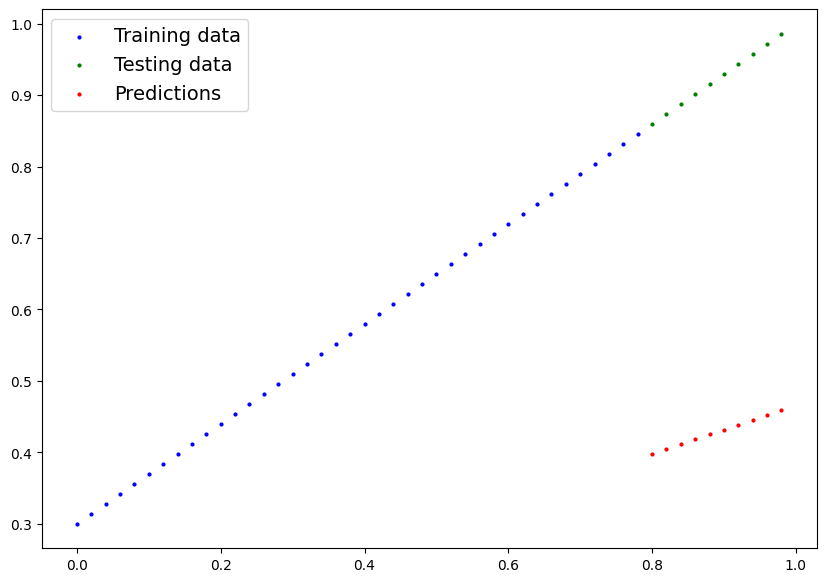

In [13]:
#making random predictions on random parameters -> will improve
plot_predictions(predictions=y_preds)

### Train Model
* Moving from unknown parameters to known parameters
* Improved representation of the data
* Measured incorrectness using a loss function
* Weights and bias will be tweeked to decrease the result of the loss function

In [14]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [15]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [16]:
#Setup a loss function
loss_fn = nn.L1Loss()

#Setup an Optimizer (stochastic gradient descent)
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.01) #lr -> learning rate -> very importatn hyperparameter

In [17]:
loss_fn

L1Loss()

### Building a training loop and a testing loop

In [27]:
from os import lseek
#epoch in a single loop through the data
epochs = 100

#loop through data in TRAINING LOOP:
for epoch in range(epochs):
  #set the model to training mode
  model_0.train() #sets all parameters to require gradients if it is an option

  #Forward pass
  y_pred = model_0(X_train)

  #Calculating loss: Mean Absolute Error (MAE)
  loss = loss_fn(y_pred, y_train) #input -> target
  print(f"LOSS:{loss}")
  #Optimizer zero grad
  optimizer.zero_grad()

  #Perform backproagration on the loss with respect to model parameters
  loss.backward()

  #perform gradient decent
  optimizer.step()

  #TESTING:
  model_0.eval() #turns off gradient tracking
  with torch.inference_mode():# turns off gradient tracking and a few other things
    #Do forward pass
    test_pred = model_0(X_test)

    #calculate loss
    test_loss = loss_fn(test_pred, y_test)

  #print results
  if epoch % 10 == 0:
    print(f"Epoch: {epoch} | Test: {loss}, Test loss: {test_loss}")


  print(model_0.state_dict())

LOSS:0.24375534057617188
Epoch: 0 | Test: 0.24375534057617188, Test loss: 0.40023916959762573
OrderedDict({'weights': tensor([0.3640]), 'bias': tensor([0.1988])})
LOSS:0.23223432898521423
OrderedDict({'weights': tensor([0.3679]), 'bias': tensor([0.2088])})
LOSS:0.22071333229541779
OrderedDict({'weights': tensor([0.3718]), 'bias': tensor([0.2188])})
LOSS:0.20919232070446014
OrderedDict({'weights': tensor([0.3757]), 'bias': tensor([0.2288])})
LOSS:0.1976713240146637
OrderedDict({'weights': tensor([0.3796]), 'bias': tensor([0.2388])})
LOSS:0.18615034222602844
OrderedDict({'weights': tensor([0.3835]), 'bias': tensor([0.2488])})
LOSS:0.1746293306350708
OrderedDict({'weights': tensor([0.3874]), 'bias': tensor([0.2588])})
LOSS:0.16310831904411316
OrderedDict({'weights': tensor([0.3913]), 'bias': tensor([0.2688])})
LOSS:0.1515873372554779
OrderedDict({'weights': tensor([0.3952]), 'bias': tensor([0.2788])})
LOSS:0.14006635546684265
OrderedDict({'weights': tensor([0.3991]), 'bias': tensor([0.288

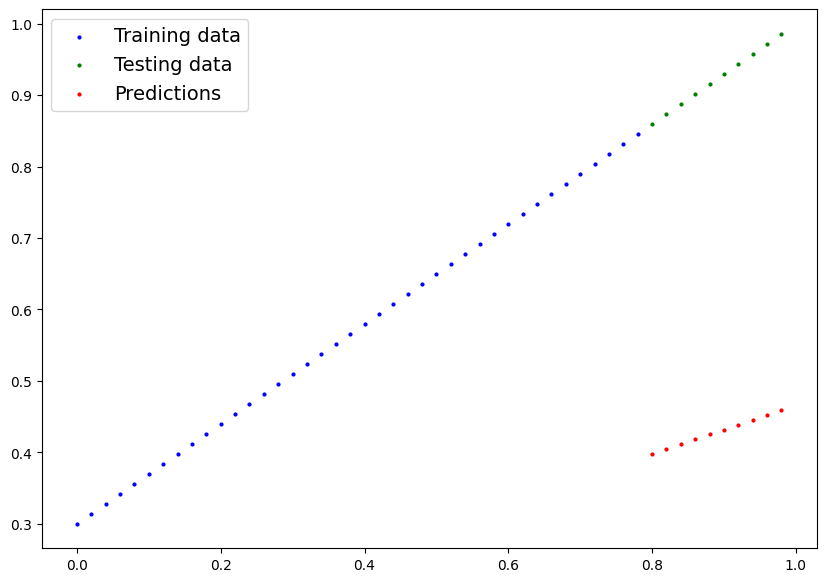

In [19]:
#Old predictions
with torch.inference_mode():
  y_preds_new = model_0(X_test)
  plot_predictions(predictions=y_preds)


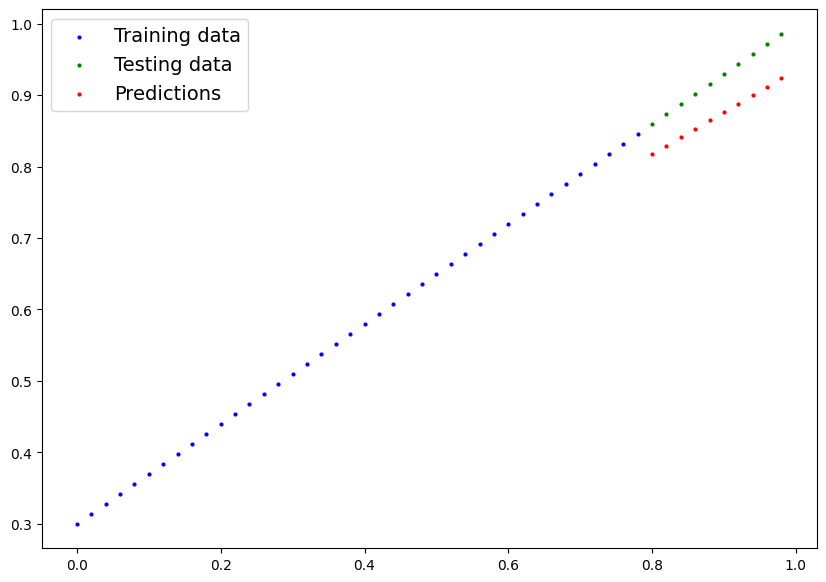

In [28]:
#new Predictions after running a few loops, much better
with torch.inference_mode():
  y_preds_new = model_0(X_test)
  plot_predictions(predictions=y_preds_new)